# Occupation Distance Analysis

Clara Krämer, March 2025

### Notebook purpose:
- Calculates the amount of viable transitions for each selected skill per occupation in terms of occupational similarity thresholds
- Uses the ESCO Skill-Occupation Matrix Tables
- (Directly maps from 125 ISCO 3D occupations to 290 ESCO skill groups)?


#### 1. Load and prepare input for re-skilling scenarios

!! Important !! Select the specific environment/kernel for this notebook

In [ ]:
# PythonProject/Simulating-Re-Skilling-Journeys/.venv_numba/bin/python
# Python 3.12

# This environment runs with an old numpy version in order to import relevant parts of mapping_career_causeways (Nesta UK module)

Import packages from requirements and necessary patches

In [1]:
from awscli.customizations.cloudformation.yamlhelper import yaml_parse

In [1]:
import sys
from pathlib import Path

# Set the working directory to the parent folder (project root)
os.chdir("/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/")  # Ensure you're in the project's root directory

# Add 'src' directory to the Python path
sys.path.append(str(Path().resolve() / "src"))
# Optionally, print the sys.path to verify that the module directory was added
print(sys.path)

['/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys', '/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev', '/Applications/PyCharm.app/Contents/plugins/python/helpers-pro/jupyter_debug', '/opt/anaconda3/lib/python312.zip', '/opt/anaconda3/lib/python3.12', '/opt/anaconda3/lib/python3.12/lib-dynload', '', '/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv_numba/lib/python3.12/site-packages', '/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/src']


In [2]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from mapping_career_causeways.compare_nodes_utils import find_closest

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.5)
pd.options.display.float_format = "{:,.2f}".format

# load paths
from src import utils
from data.framework import Esco

useful_paths = utils.UsefulPaths()

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

Prepare occupation-skills matrix

In [3]:
%%time
from data.framework import Esco

esco = Esco()

# Override the base directory to point inside "src"
#esco.data_dir = "/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/src/data"
#esco.data_raw = f"{esco.data_dir}/raw"  # Update the raw data directory

CPU times: user 47 μs, sys: 13 μs, total: 60 μs
Wall time: 63.9 μs


In [4]:
# Read occupations with their ISCO level
occ = esco.occupations
occ["isco_3_digit"] = occ["iscoGroup"].astype(str).str.slice(stop=3)

# read raw occ-skills matrix

# choose OSM version (weighted/unweighted)
osm_version = "weighted"

# read bipartite adjecency matrix for occupations and skills
occ_skills_mat = esco.read_occ_skills_matrix(return_version=osm_version)

# Create multiindex
arrays = [occ.conceptUri.values, occ.isco_3_digit.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["concept_uri", "isco_3_digit"])
assert np.alltrue(occ_skills_mat.index.values == occ.conceptUri.values)

# Aggregate original occ-skills matrix to ISCO 3-digit level
occ_skills_mat.index = index
occ_skills_mat_isco3 = occ_skills_mat.groupby(
    occ_skills_mat.index.get_level_values(1)
).mean()

# Calculate occupation similarity matrix at ISCO 3-digit level
occ_sims_isco3 = np.matmul(
    occ_skills_mat_isco3.values, occ_skills_mat_isco3.values.transpose()
)

# Find labels for isco codes
isco_groups_labels = pd.merge(
    pd.DataFrame(data=occ_skills_mat_isco3.index.values.astype(str), columns=["code"]),
    esco.isco_groups[["code", "conceptUri", "preferredLabel"]],
    on="code",
    how="left",
)

arrays = [
    isco_groups_labels.conceptUri.values,
    isco_groups_labels.preferredLabel.values,
]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["occ_uri", "occ"])

# to df
df_occ_sims_isco3 = pd.DataFrame(index=index, columns=index, data=occ_sims_isco3)

In [43]:
occ

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_3_digit
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,265
1,Occupation,http://data.europa.eu/esco/occupation/000e93a3...,8121,metal drawing machine operator,metal drawing machine technician\nmetal drawin...,NaN,released,2016-07-05T17:09:43Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Metal drawing machine operators set up and ope...,8121.4,812
2,Occupation,http://data.europa.eu/esco/occupation/0019b951...,7543,precision device inspector,inspector of precision instruments\nprecision ...,NaN,released,2016-07-06T09:21:20Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Precision device inspectors make sure precisio...,7543.10.3,754
3,Occupation,http://data.europa.eu/esco/occupation/0022f466...,3155,air traffic safety technician,air traffic safety electronics hardware specia...,NaN,released,2017-01-17T11:40:37Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Air traffic safety technicians provide technic...,3155.1,315
4,Occupation,http://data.europa.eu/esco/occupation/002da35b...,2431,hospitality revenue manager,hospitality revenues manager\nyield manager\nh...,NaN,released,2017-01-17T13:33:42Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Hospitality revenue managers maximise revenue ...,2431.9,243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3003,Occupation,http://data.europa.eu/esco/occupation/ff656b3a...,2120,demographer,demography research analyst\ndemography studie...,NaN,released,2021-12-21T13:41:38.024Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Demographers study a variety of parameters rel...,2120.2,212
3004,Occupation,http://data.europa.eu/esco/occupation/ff8d4065...,9612,sorter labourer,grader\nyard labourer\nrecycler\nrecycling sit...,NaN,released,2021-12-08T20:18:37.546Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Sorter labourers sort recyclable materials and...,9612.2,961
3005,Occupation,http://data.europa.eu/esco/occupation/ffa4dd5d...,5414,armoured car guard,armoured truck escort\ntruck escort\narmoured ...,NaN,released,2022-01-13T09:51:50.643Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Armoured car guards ensure the safe transporta...,5414.1.2,541
3006,Occupation,http://data.europa.eu/esco/occupation/ffade2f4...,2422,civil service administrative officer,government administrative officer\nlocal autho...,NaN,released,2016-07-05T16:17:26Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Civil service administrative officers perform ...,2422.1,242


Create similarity thresholds

In [5]:
q_viable = np.percentile(df_occ_sims_isco3.values.flatten(), q=96)
q_highly_viable = np.percentile(df_occ_sims_isco3.values.flatten(), q=99)

print(q_viable, q_highly_viable)

1.6163680477790219 6.5008535353535475


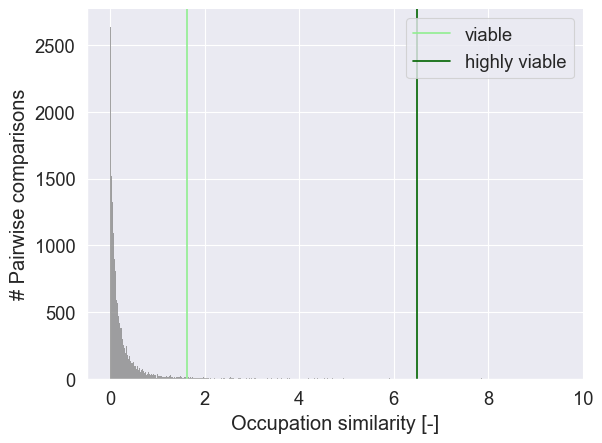

In [10]:
ax = sns.histplot(df_occ_sims_isco3.values.flatten(), color="grey")
ax.set_xlim(-0.5, 10)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Occupation similarity [-]")
plt.legend()
sns.despine()

In [37]:
# Save data

#df_occ_sims_isco3

<bound method NDFrame.head of      conceptType                                         conceptUri iscoGroup  \
0     Occupation  http://data.europa.eu/esco/occupation/00030d09...      2654   
1     Occupation  http://data.europa.eu/esco/occupation/000e93a3...      8121   
2     Occupation  http://data.europa.eu/esco/occupation/0019b951...      7543   
3     Occupation  http://data.europa.eu/esco/occupation/0022f466...      3155   
4     Occupation  http://data.europa.eu/esco/occupation/002da35b...      2431   
...          ...                                                ...       ...   
3003  Occupation  http://data.europa.eu/esco/occupation/ff656b3a...      2120   
3004  Occupation  http://data.europa.eu/esco/occupation/ff8d4065...      9612   
3005  Occupation  http://data.europa.eu/esco/occupation/ffa4dd5d...      5414   
3006  Occupation  http://data.europa.eu/esco/occupation/ffade2f4...      2422   
3007  Occupation  http://data.europa.eu/esco/occupation/ffc292f1...      8211  

Load and inspect coreness data

In [11]:
coreness = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "skills_network_metrics.csv"),
    index_col=0,
)
coreness_top_5 = coreness.sort_values("coreness", ascending=False).head(5)
coreness_top_5

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description,eigenvector_centrality,betweenness_centrality,betweenness_centrality_norm,mean_centrality,clustering_coefficient,coreness,skill_classification_esco
12391,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/e54ff029-1ce9...,skill/competence,cross-sector,train employees,train an employee\nteach employees\nupskill em...,NaN,released,2021-10-01T16:36:38.559Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Lead and guide employees through a process in ...,0.95,"2,295,023.03",0.87,0.91,0.07,1.00,neutral
3572,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/415abd43-e8e5...,skill/competence,cross-sector,use different communication channels,apply specific communication channels\noperate...,NaN,released,2016-12-20T18:56:53Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Make use of various types of communication cha...,0.68,"2,624,645.09",1.00,0.84,0.06,0.93,neutral
2856,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/339ac029-066a...,skill/competence,cross-sector,manage staff,coordinate and monitor employees\nmanage subor...,NaN,released,2016-12-20T20:30:17Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"Manage employees and subordinates, working in ...",0.82,"1,864,324.13",0.71,0.76,0.07,0.84,neutral
1821,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/21c5790c-0930...,skill/competence,cross-sector,manage budgets,NaN,NaN,released,2016-10-20T15:06:39Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"Plan, monitor and report on the budget.",0.93,"1,523,320.43",0.58,0.75,0.08,0.82,neutral
732,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0da516ee-e70e...,skill/competence,cross-sector,communicate with customers,talk with customers\ncommunicate with clients\...,NaN,released,2021-12-16T09:30:47.116Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Respond to and communicate with customers in t...,0.85,"1,732,220.14",0.66,0.75,0.08,0.81,neutral


#### 2. Prepare skill lists for reskilling scenarios

Create list of occupations for explanatory purposes

In [12]:
# Coal mining jobs

coal_occs = {
    "Mining, manufacturing and construction supervisors": "312",
    "Mining and mineral processing plant operators": "811",
    "Manufacturing, mining, construction, and distribution managers": "132",
    "Mining and construction labourers": "931",
}

In [ ]:
# Others unviable to decarbonize?

# diesel engine mechanic? -> what in ISCO 3 digit?


Tailored re-skilling: Which skills add the most additional viable transitions per occupation?

a) for all occupations

In [41]:
all_occs = {}

for i, s in isco_groups_labels.iterrows():
    all_occs[s.preferredLabel] = s.code

In [20]:
%%time

calc_upskilling_v2 = True
occ_codes = occ_skills_mat_isco3.index.values.tolist()

if calc_upskilling_v2:
    upskilling_tailored_impact = []
    for occ_label, occ_code in all_occs.items():
        print(occ_code, occ_label)
        # find index of occ
        idx_occ = occ_codes.index(occ_code)

        for idx_new_skill, new_skill in coreness.iterrows():

            # add skill to occ skill profile
            occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
            occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

            # recalc occ sim matrix
            occ_sims_isco3_upskilling = np.matmul(
                occ_skills_mat_isco3_upskilling.values,
                occ_skills_mat_isco3_upskilling.values.transpose(),
            )

            # New viable transitions unlocked?
            n_new_viable_transitions = (
                np.tril(occ_sims_isco3_upskilling).flatten() > q_viable
            ).sum() - (np.tril(df_occ_sims_isco3.values).flatten() > q_viable).sum()

            # collect data
            upskilling_tailored_impact.append(
                [
                    occ_label,
                    new_skill.preferredLabel,
                    new_skill.coreness,
                    n_new_viable_transitions,
                ]
            )

    # to df
    df_upskilling_tailored_impact = pd.DataFrame(
        data=upskilling_tailored_impact,
        columns=["ISCO3D_label", "skill_label", "coreness", "new_viable_transitions"],
    )
    df_upskilling_tailored_impact.to_csv(
        os.path.join(
            useful_paths.data_interim,
            "upskilling_analysis",
            "upskilling_tailored_all_skills_per_isco3d_occupation.csv",
        )
    )

011 Commissioned armed forces officers
021 Non-commissioned armed forces officers


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10f655010>>
Traceback (most recent call last):
  File "/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv_numba/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


KeyboardInterrupt: 

In [86]:
# subset the general list to top 100 skills per occupation
# note: the list is not deterministic and sorts skills with the same number of viable transitions randomly!

df_upskilling_tailored_impact = pd.read_csv(
        os.path.join(
            useful_paths.data_interim,
            "upskilling_analysis",
            "upskilling_tailored_all_skills_per_isco3d_occupation.csv",
        )
    )

top_tailored_skills_per_occ = []
for occ_label, occ_code in all_occs.items():
    top_tailored_skills = (
        df_upskilling_tailored_impact.loc[df_upskilling_tailored_impact.ISCO3D_label == occ_label]
        .sort_values("new_viable_transitions", ascending=False)
        .head(100)
    )
    top_tailored_skills_per_occ.append(top_tailored_skills)

# to table
df_top_tailored_skills_per_occ = pd.concat(top_tailored_skills_per_occ, axis=0)

df_top_tailored_skills_per_occ.reset_index(drop=True).to_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_tailored_100_skills_per_isco3d_occupation.csv",
    ),
)

b) for coal occupations

In [69]:
# Take the top tailored skills df above and substract only the coal occs.

# Load dataframe
df_top_tailored_skills_per_occ = pd.read_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_tailored_100_skills_per_isco3d_occupation.csv",
    ),
)

# Filter tailored skills data for coal occupations only using labels
coal_occs_labels = list(coal_occs.keys())  # Extract labels from dictionary

df_upskilling_tailored_impact_coal = df_top_tailored_skills_per_occ[
    df_top_tailored_skills_per_occ['ISCO3D_label'].isin(coal_occs_labels)
].copy()

df_upskilling_tailored_impact_coal_pivoted = df_upskilling_tailored_impact_coal.pivot_table(
    columns="ISCO3D_label", index="skill_label", values="new_viable_transitions"
)

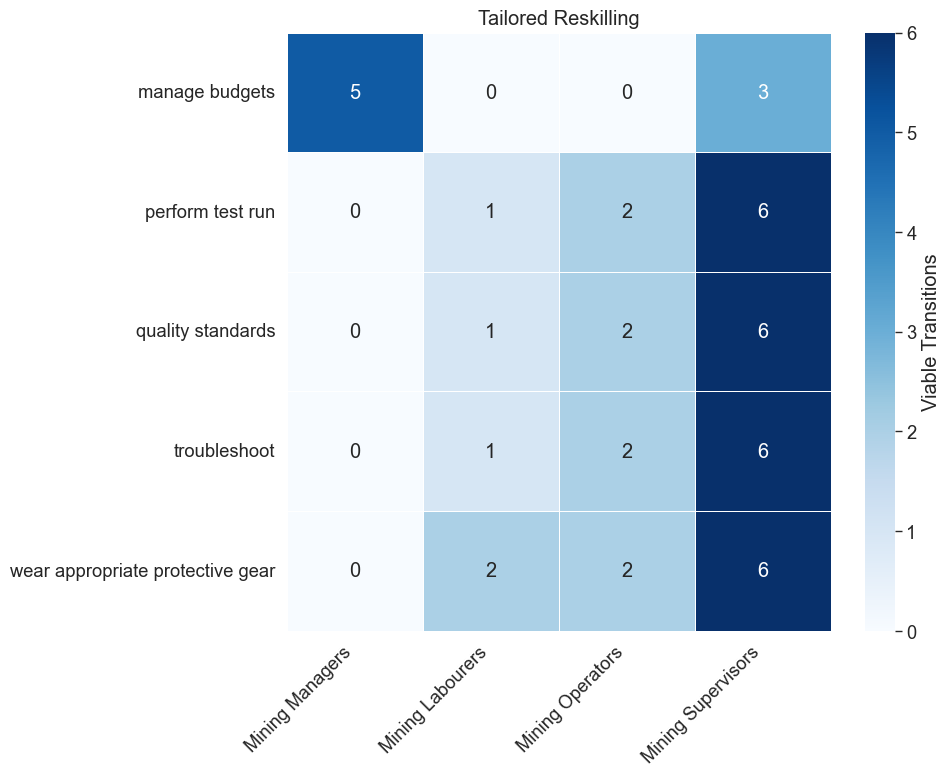

In [77]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Identify Skills with Highest Viable Transitions per Occupation
highest_transitions = df_upskilling_tailored_impact_coal.groupby("ISCO3D_label")['new_viable_transitions'].max()

# Step 2: Identify the Skills That Match Those Highest Transition Values
df_top_skills = df_upskilling_tailored_impact_coal[
    df_upskilling_tailored_impact_coal.apply(
        lambda row: row['new_viable_transitions'] == highest_transitions[row['ISCO3D_label']], axis=1
    )
]

# Step 3: Filter Full Data for These Skills to Capture All Occurrences
skills_with_max_transitions = df_top_skills['skill_label'].unique()
df_top_skills_all_occ = df_upskilling_tailored_impact_coal[
    df_upskilling_tailored_impact_coal['skill_label'].isin(skills_with_max_transitions)
]

# Step 4: Filter the Top 5 Skills Based on Highest 'new_viable_transitions'
top_5_skills = df_top_skills_all_occ.groupby('skill_label')['new_viable_transitions'].max().nlargest(5).index
df_top_skills_all_occ = df_top_skills_all_occ[df_top_skills_all_occ['skill_label'].isin(top_5_skills)]


# Step 5: Pivot for Heatmap
df_top_skills_pivoted = df_top_skills_all_occ.pivot_table(
    columns="skill_label",
    index="ISCO3D_label",
    values="new_viable_transitions",
    fill_value=0  # Ensure zeros are displayed correctly
)

# Step 6: Abbreviate Occupation Names
abbr_mapping = {
    "Manufacturing, mining, construction, and distribution managers": "Mining Managers",
    "Mining and construction labourers": "Mining Labourers",
    "Mining and mineral processing plant operators": "Mining Operators",
    "Mining, manufacturing and construction supervisors": "Mining Supervisors"
}
df_top_skills_pivoted.rename(index=abbr_mapping, inplace=True)

# Step 7: Plotting
output_dir = "/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_viable_transitions_selected-occs"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "heatmap_viable_transitions_tailored_coal.png")

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_top_skills_pivoted.transpose(),
    cmap="Blues",
    annot=True,
    linewidths=0.5,
    cbar_kws={'label': 'Viable Transitions'}
)

# Remove axis labels for cleaner look
plt.xlabel("")  # Remove 'ISCO3D_label'
plt.ylabel("")  # Remove 'skill_label'

# Improved formatting
plt.title("Tailored Reskilling")
plt.xticks(rotation=45, ha='right')  # Occupation names more readable
plt.yticks(rotation=0)               # Skill names aligned horizontally

# Save the figure
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

Broad re-skilling: How many additional viable transitions are unlocked by sequentially adding the top core skills of the network in general?

a) for all occupations

In [80]:
# Load dataframe
df_upskilling_tailored_impact = pd.read_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_tailored_all_skills_per_isco3d_occupation.csv",
    ),
)

# Step 1: Create filtered DataFrames for each skill group size
core_skills_groups = {5: [], 15: [], 30: [], 100: []}

# Step 2: Iterate through each occupation and collect top core skills
for occ_label in df_upskilling_tailored_impact['ISCO3D_label'].unique():

    # Filter data for each occupation
    occ_skills = df_upskilling_tailored_impact[
        df_upskilling_tailored_impact['ISCO3D_label'] == occ_label
    ].sort_values("coreness", ascending=False)  # Sort by coreness

    # Step 3: Append top 5, 15, 30, and 100 core skills
    for n_skills in core_skills_groups.keys():
        core_skills_groups[n_skills].append(occ_skills.head(n_skills))

# Step 4: Combine the collected data for each skill group size
df_top100 = pd.concat(core_skills_groups[100]).reset_index(drop=True)

# Step 5: Save each resulting DataFrame to CSV
file_paths = {
    'upskilling_broad_100_skills_per_isco3d_occupation.csv': df_top100
}

for file_name, df in file_paths.items():
    df.to_csv(
        os.path.join(useful_paths.data_interim, "upskilling_analysis", file_name),
        index=False
    )

✅ Successfully saved all core skill groups to CSV.


In [99]:
# Merge information on skill aggregation from the other dataframe until figured out how this info was retreived in the first place

import pandas as pd
import os

# Step 1: Load the DataFrames
df_top100 = pd.read_csv(os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_broad_100_skills_per_isco3d_occupation.csv",
    ),
)
df_merged_source = pd.read_csv(os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_best_100_skills_per_isco3d_occupation_merged.csv",
    ),
)

# Step 2: Ensure column types are consistent
df_top100['ISCO3D_label'] = df_top100['ISCO3D_label'].astype(str)
df_merged_source['code_occ'] = df_merged_source['code_occ'].astype(str)

# Step 3: Merge DataFrames
# 1. Add `code_occ` based on `ISCO3D_label`
df_top100_merged = pd.merge(
    df_top100,
    df_merged_source[['ISCO3D_label', 'code_occ']].drop_duplicates(),
    on='ISCO3D_label',
    how='left'
)

# 2. Add `idx_skill` and `reuseLevel` based on `skill_label`
df_top100_merged = pd.merge(
    df_top100_merged,
    df_merged_source[['skill_label', 'idx_skill', 'reuseLevel']].drop_duplicates(),
    on='skill_label',
    how='left'
)

# Step 4: Sort DataFrame by 'ISCO3D_label' and 'coreness' in descending order
df_top100_merged_sorted = df_top100_merged.sort_values(by=['code_occ', 'coreness'], ascending=[True, False]).reset_index(drop=True)


# Step 5: Save the resulting DataFrame
output_file = os.path.join(
    useful_paths.data_interim,
    "upskilling_analysis",
    "upskilling_broad_100_skills_per_isco3d_occupation_merged.csv"
)
df_top100_merged_sorted.to_csv(output_file, index=False)

In [ ]:
#TO DO: Check whether the above file is correct before using!!

b) for coal occupations

In [70]:
# Load dataframe
df_top_broad_skills_per_occ = pd.read_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_broad_100_skills_per_isco3d_occupation.csv",
    ),
)

# Filter tailored skills data for coal occupations only using labels
coal_occs_labels = list(coal_occs.keys())  # Extract labels from dictionary

df_upskilling_broad_impact_coal = df_top_broad_skills_per_occ[
    df_top_broad_skills_per_occ['ISCO3D_label'].isin(coal_occs_labels)
].copy()

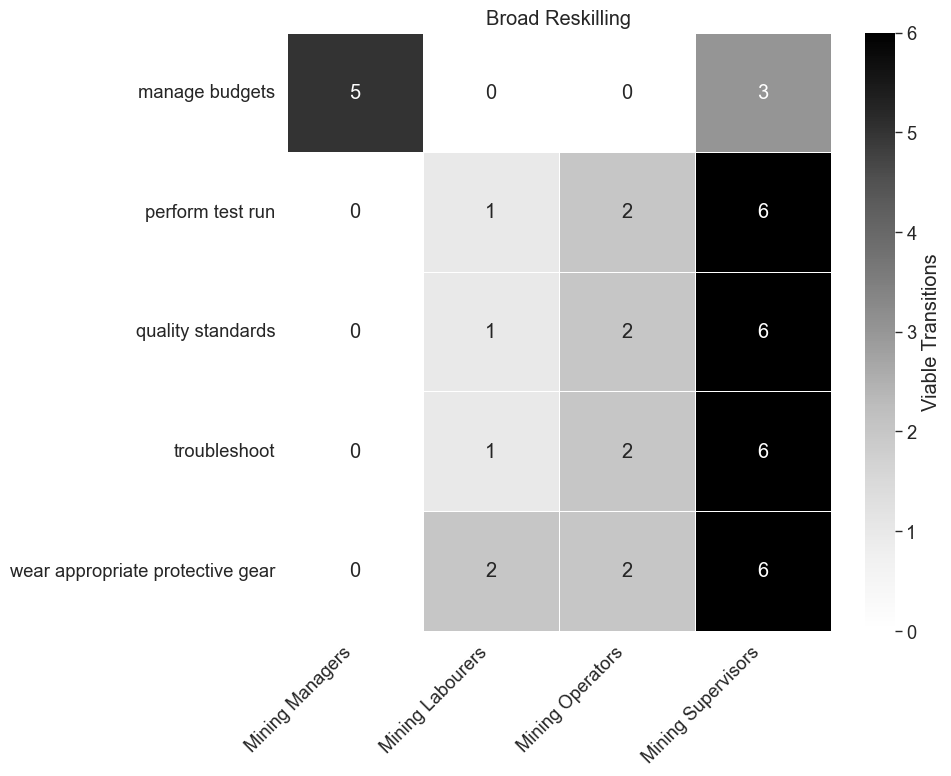

In [78]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Identify Skills with Highest Viable Transitions per Occupation
highest_transitions = df_upskilling_broad_impact_coal.groupby("ISCO3D_label")['new_viable_transitions'].max()

# Step 2: Identify the Skills That Match Those Highest Transition Values
df_top_skills = df_upskilling_broad_impact_coal[
    df_upskilling_broad_impact_coal.apply(
        lambda row: row['new_viable_transitions'] == highest_transitions[row['ISCO3D_label']], axis=1
    )
]

# Step 3: Filter Full Data for These Skills to Capture All Occurrences
skills_with_max_transitions = df_top_skills['skill_label'].unique()
df_top_skills_all_occ = df_upskilling_broad_impact_coal[
    df_upskilling_broad_impact_coal['skill_label'].isin(skills_with_max_transitions)
]

# Step 4: Filter the Top 5 Skills Based on Highest 'new_viable_transitions'
top_5_skills = df_top_skills_all_occ.groupby('skill_label')['new_viable_transitions'].max().nlargest(5).index
df_top_skills_all_occ = df_top_skills_all_occ[df_top_skills_all_occ['skill_label'].isin(top_5_skills)]


# Step 5: Pivot for Heatmap
df_top_skills_pivoted = df_top_skills_all_occ.pivot_table(
    columns="skill_label",
    index="ISCO3D_label",
    values="new_viable_transitions",
    fill_value=0  # Ensure zeros are displayed correctly
)

# Step 6: Abbreviate Occupation Names
abbr_mapping = {
    "Manufacturing, mining, construction, and distribution managers": "Mining Managers",
    "Mining and construction labourers": "Mining Labourers",
    "Mining and mineral processing plant operators": "Mining Operators",
    "Mining, manufacturing and construction supervisors": "Mining Supervisors"
}
df_top_skills_pivoted.rename(index=abbr_mapping, inplace=True)

# Step 7: Plotting
output_dir = "/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_viable_transitions_selected-occs"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "heatmap_viable_transitions_broad_coal.png")

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_top_skills_pivoted.transpose(),
    cmap="Grays",
    annot=True,
    linewidths=0.5,
    cbar_kws={'label': 'Viable Transitions'}
)

# Remove axis labels for cleaner look
plt.xlabel("")  # Remove 'ISCO3D_label'
plt.ylabel("")  # Remove 'skill_label'

# Improved formatting
plt.title("Broad Reskilling")
plt.xticks(rotation=45, ha='right')  # Occupation names more readable
plt.yticks(rotation=0)               # Skill names aligned horizontally

# Save the figure
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

Targeted re-skilling: Which green skills add the most additional viable transitions per occupation?



a) for all occupations

In [135]:
# Digital and green skills are labelled in ESCO. However, the digComp labelling identifies only 22 skills.

import pandas as pd
import os

# Load the primary dataframe
df_upskilling_tailored_impact = pd.read_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_tailored_all_skills_per_isco3d_occupation.csv",
    )
)

# Load the green skills data
df_green_skills = pd.read_csv(
    os.path.join(
        useful_paths.data_raw,
        "esco",
        "v1.1.0",
        "greenSkillsCollection_en.csv"
    )
)

# Step 0: Ensure numeric type for viable transitions
df_upskilling_tailored_impact['new_viable_transitions'] = pd.to_numeric(
    df_upskilling_tailored_impact['new_viable_transitions'], errors='coerce'
).fillna(0)  # Fill NaN values with zero to standardize across datasets

# Step 1: Filter for green skills only
green_skills_set = set(df_green_skills['preferredLabel'].unique())  # Efficient lookup
df_green_upskilling = df_upskilling_tailored_impact[
    df_upskilling_tailored_impact['skill_label'].isin(green_skills_set)
]

# Step 2: Create filtered DataFrames for each skill group size
df_top5, df_top15, df_top30, df_top100 = [], [], [], []

# Step 3: Iterate through each occupation and collect top green skills
for occ_label in df_green_upskilling['ISCO3D_label'].unique():

    # Filter data for each occupation
    occ_skills = df_green_upskilling[
        df_green_upskilling['ISCO3D_label'] == occ_label
    ].sort_values(
        ["new_viable_transitions", "coreness"],  # Added coreness as a secondary criterion
    ascending=[False, False]  # Sort both in descending order
    )

    # Collect top 5, 15, 30, and 100 green skills
    df_top100.append(occ_skills.head(100))

# Step 4: Combine collected data and reset index
df_top100 = pd.concat(df_top100).reset_index(drop=True)

# Step 5: Save each resulting DataFrame to CSV
df_top100.to_csv(
    os.path.join(useful_paths.data_interim, "upskilling_analysis", "upskilling_green_100_skills_per_isco3d_occupation.csv"),
    index=False
)

In [60]:
# Merge information on skill aggregation from the other dataframe until figured out how this info was retreived in the first place

import pandas as pd
import os

# Step 1: Load the DataFrames
df_top100 = pd.read_csv(os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_green_100_skills_per_isco3d_occupation.csv",
    ),
)
df_merged_source = pd.read_csv(os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_best_100_skills_per_isco3d_occupation_merged.csv",
    ),
)

# Step 2: Ensure column types are consistent
df_top100['ISCO3D_label'] = df_top100['ISCO3D_label'].astype(str)
df_merged_source['code_occ'] = df_merged_source['code_occ'].astype(str)

# Step 3: Merge DataFrames
# 1. Add `code_occ` based on `ISCO3D_label`
df_top100_merged = pd.merge(
    df_top100,
    df_merged_source[['ISCO3D_label', 'code_occ']].drop_duplicates(),
    on='ISCO3D_label',
    how='left'
)

# 2. Add `idx_skill` and `reuseLevel` based on `skill_label`
df_top100_merged = pd.merge(
    df_top100_merged,
    df_merged_source[['skill_label', 'idx_skill', 'reuseLevel']].drop_duplicates(),
    on='skill_label',
    how='left'
)

# Step 4: Sort DataFrame by 'ISCO3D_label' and 'coreness' in descending order
df_top100_merged_sorted = df_top100_merged.sort_values(by=['code_occ', 'coreness'], ascending=[True, False]).reset_index(drop=True)


# Step 5: Save the resulting DataFrame
output_file = os.path.join(
    useful_paths.data_interim,
    "upskilling_analysis",
    "upskilling_green_100_skills_per_isco3d_occupation_merged.csv"
)
df_top100_merged_sorted.to_csv(output_file, index=False)

b) for coal occupations

In [71]:
# Load dataframe
df_top_green_skills_per_occ = pd.read_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_green_100_skills_per_isco3d_occupation.csv",
    ),
)

# Filter tailored skills data for coal occupations only using labels
coal_occs_labels = list(coal_occs.keys())  # Extract labels from dictionary

df_upskilling_green_impact_coal = df_top_green_skills_per_occ[
    df_top_green_skills_per_occ['ISCO3D_label'].isin(coal_occs_labels)
].copy()

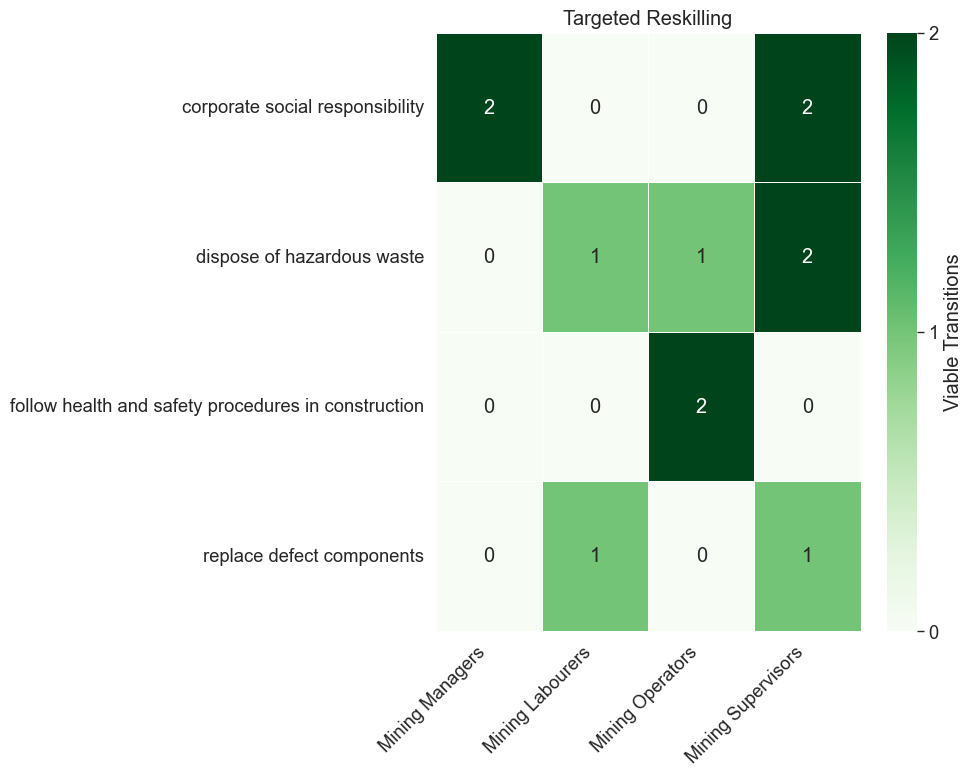

In [79]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Identify Skills with Highest Viable Transitions per Occupation
highest_transitions = df_upskilling_green_impact_coal.groupby("ISCO3D_label")['new_viable_transitions'].max()

# Step 2: Identify the Skills That Match Those Highest Transition Values
df_top_skills = df_upskilling_green_impact_coal[
    df_upskilling_green_impact_coal.apply(
        lambda row: row['new_viable_transitions'] == highest_transitions[row['ISCO3D_label']], axis=1
    )
]

# Step 3: Filter Full Data for These Skills to Capture All Occurrences
skills_with_max_transitions = df_top_skills['skill_label'].unique()
df_top_skills_all_occ = df_upskilling_green_impact_coal[
    df_upskilling_green_impact_coal['skill_label'].isin(skills_with_max_transitions)
]

# Step 4: Filter the Top 5 Skills Based on Highest 'new_viable_transitions'
top_5_skills = df_top_skills_all_occ.groupby('skill_label')['new_viable_transitions'].max().nlargest(5).index
df_top_skills_all_occ = df_top_skills_all_occ[df_top_skills_all_occ['skill_label'].isin(top_5_skills)]


# Step 5: Pivot for Heatmap
df_top_skills_pivoted = df_top_skills_all_occ.pivot_table(
    columns="skill_label",
    index="ISCO3D_label",
    values="new_viable_transitions",
    fill_value=0  # Ensure zeros are displayed correctly
)

# Step 6: Abbreviate Occupation Names
abbr_mapping = {
    "Manufacturing, mining, construction, and distribution managers": "Mining Managers",
    "Mining and construction labourers": "Mining Labourers",
    "Mining and mineral processing plant operators": "Mining Operators",
    "Mining, manufacturing and construction supervisors": "Mining Supervisors"
}
df_top_skills_pivoted.rename(index=abbr_mapping, inplace=True)

# Step 7: Plotting
output_dir = "/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_viable_transitions_selected-occs"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "heatmap_viable_transitions_green_coal.png")

# Define max viable transitions to set vmin and vmax
max_value = int(df_top_skills_pivoted.max().max())

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_top_skills_pivoted.transpose(),
    cmap="Greens",
    annot=True,
    linewidths=0.5,
    vmin=0,  # Force the lower boundary as zero
    vmax=max_value,  # Force upper limit to highest value
    cbar_kws={'label': 'Viable Transitions', 'ticks': range(0, max_value + 1)}
)

# Remove axis labels for cleaner look
plt.xlabel("")  # Remove 'ISCO3D_label'
plt.ylabel("")  # Remove 'skill_label'

# Improved formatting
plt.title("Targeted Reskilling")
plt.xticks(rotation=45, ha='right')  # Occupation names more readable
plt.yticks(rotation=0)               # Skill names aligned horizontally

# Save the figure
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

Create comparison graph

/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_67995/2030258354.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_skills_all_occ['skill_label'] = df_top_skills_all_occ['skill_label'].str.replace('-Transferable', '', regex=False)
/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_67995/2030258354.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_skills_all_occ['skill_label'] = df_top_skills_all_occ['skill_label'].str.replace('-Transferable', '', regex=False)
/var/folde

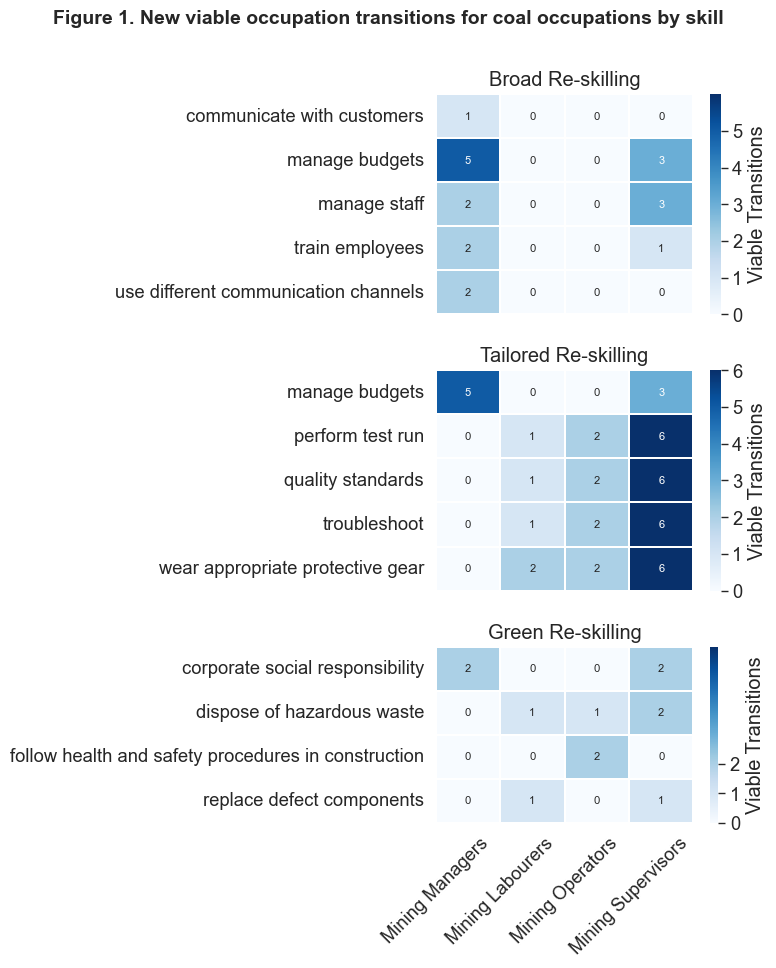

In [75]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the output directory
output_dir = "/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_viable_transitions_selected-occs"

# Step 1: Define DataFrames
dataframes = {
    "Broad Reskilling": (df_upskilling_broad_impact_coal, "Blues"),
    "Tailored Reskilling": (df_upskilling_tailored_impact_coal, "Blues"),
    "Green Reskilling": (df_upskilling_green_impact_coal, "Blues")
}

# Step 2: Prepare Data
def prepare_heatmap_data(df, tailored=False):
    highest_transitions = df.groupby("ISCO3D_label")['new_viable_transitions'].max()

    df_top_skills = df[
        df.apply(
            lambda row: row['new_viable_transitions'] == highest_transitions[row['ISCO3D_label']], axis=1
        )
    ]

    skills_with_max_transitions = df_top_skills['skill_label'].unique()
    df_top_skills_all_occ = df[
        df['skill_label'].isin(skills_with_max_transitions)
    ]

    # 🔹 Improved: Select **Top 5 Skills Overall** for Tailored Skills
    if tailored:
        top_5_skills = (
            df.groupby('skill_label')['new_viable_transitions'].max()
            .nlargest(5)                # Select top 5 highest values overall
            .index
        )
        df_top_skills_all_occ = df[df['skill_label'].isin(top_5_skills)]

    # Clean skill labels
    df_top_skills_all_occ['skill_label'] = df_top_skills_all_occ['skill_label'].str.replace('-Transferable', '', regex=False)

    df_top_skills_pivoted = df_top_skills_all_occ.pivot_table(
        index="skill_label",    # Skills as rows
        columns="ISCO3D_label", # Occupations as columns
        values="new_viable_transitions",
        fill_value=0
    )

    # Abbreviate Occupation Names
    abbr_mapping = {
        "Manufacturing, mining, construction, and distribution managers": "Mining Managers",
        "Mining and construction labourers": "Mining Labourers",
        "Mining and mineral processing plant operators": "Mining Operators",
        "Mining, manufacturing and construction supervisors": "Mining Supervisors"
    }
    df_top_skills_pivoted.rename(columns=abbr_mapping, inplace=True)

    return df_top_skills_pivoted

# Step 3: Generate Heatmaps
# Dynamically calculate figure height based on the number of rows (skills)
num_rows_tailored = prepare_heatmap_data(df_upskilling_tailored_impact_coal, tailored=True).shape[0]
num_rows_transferable = prepare_heatmap_data(df_upskilling_broad_impact_coal).shape[0]
num_rows_green = prepare_heatmap_data(df_upskilling_green_impact_coal).shape[0]

# Adjust height ratios based on row counts
total_rows = num_rows_tailored + num_rows_transferable + num_rows_green
height_ratios = [num_rows_tailored / total_rows, num_rows_transferable / total_rows, num_rows_green / total_rows]

fig, axes = plt.subplots(3, 1, figsize=(8, 10), gridspec_kw={'height_ratios': height_ratios})

for idx, (title, (df, cmap)) in enumerate(dataframes.items()):
    is_tailored = title == "Tailored Reskilling"
    heatmap_data = prepare_heatmap_data(df, tailored=is_tailored)

    max_value = int(heatmap_data.max().max())  # Set the max range for color bar ticks

    sns.heatmap(
        heatmap_data,
        cmap=cmap,
        annot=True,
        annot_kws={"size": 8},  # 🔹 Smaller text size
        linewidths=0.3,         # 🔹 Reduced spacing for compact look
        square=False,           # 🔹 Disabled 'square' to control cell sizing via ratios
        cbar_kws={'label': 'Viable Transitions', 'ticks': range(0, max_value + 1)},
        vmin=0, vmax=6,
        ax=axes[idx],
        yticklabels=True,
        xticklabels=False if idx < 2 else True
    )

    axes[idx].set_title(title)
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("")

# Display Occupation Names Only on the Bottom Graph
axes[2].set_xticks(range(len(heatmap_data.columns)))
axes[2].set_xticklabels(heatmap_data.columns, rotation=45, ha='center')

plt.tight_layout()

# Add main title
plt.suptitle("Figure 1. New viable occupation transitions for coal occupations by skill", fontsize=14, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Step 4: Save the Plot
output_file = os.path.join(output_dir, "heatmap_viable_transitions_combined_compact.png")
plt.savefig(output_file, dpi=300, bbox_inches="tight")

plt.show()

In [80]:
# Possible cleaner alternative but needs assignment of the dataframes first to work.

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Output path
output_dir = "/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_viable_transitions_selected-occs"
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "heatmap_viable_transitions_combined.png")

# Color map and axis formatting
cmap = "Blues"
annot_kws = {"size": 8}
linewidths = 0.5

# Title mapping
titles = ["Broad Reskilling", "Targeted Reskilling", "Tailored Reskilling"]

# List of pivoted DataFrames from your three heatmaps (in desired order)
pivoted_dfs = [
    df_top_skills_pivoted_broad,    # from Broad heatmap
    df_top_skills_pivoted_green,    # from Green/Targeted heatmap
    df_top_skills_pivoted_tailored  # from Tailored heatmap
]

# Create vertically stacked plots
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for idx, ax in enumerate(axes):
    data = pivoted_dfs[idx].transpose()
    vmax = int(max([df.values.max() for df in pivoted_dfs]))

    sns.heatmap(
        data,
        cmap=cmap,
        annot=True,
        linewidths=linewidths,
        cbar=(idx == 2),  # Only show color bar in last heatmap
        cbar_kws={'label': 'Viable Transitions', 'ticks': range(0, vmax + 1)} if idx == 2 else None,
        vmin=0,
        vmax=vmax,
        xticklabels=(idx == 2),
        yticklabels=True,
        ax=ax
    )
    ax.set_title(titles[idx], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Adjust x-axis labels on last heatmap
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')

# Main title
plt.suptitle("Figure 1. New viable occupation transitions for coal mining occupations by skill",
             fontsize=14, fontweight='bold', y=0.93)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'df_top_skills_pivoted_broad' is not defined

#### 3. Add skills metadata (tbc)
- classification labels
- network metrics
- classification shares of ISCO occupations
- (to do: add also higher ESCO hierarchies)

In [41]:
df_upskilling_impact_v2

,ISCO3D_label,skill_label,coreness,new_viable_transitions
0,Commissioned armed forces officers,manage musical staff,0.00,0
1,Commissioned armed forces officers,supervise correctional procedures,0.00,0
2,Commissioned armed forces officers,apply anti-oppressive practices,0.01,0
3,Commissioned armed forces officers,control compliance of railway vehicles regulat...,0.05,0
4,Commissioned armed forces officers,identify available services,0.00,0
...,...,...,...,...
1736370,Other elementary workers,remediate healthcare user's occupational perfo...,0.00,0
1736371,Other elementary workers,install transport equipment lighting,0.02,0
1736372,Other elementary workers,natural language processing,0.02,0
1736373,Other elementary workers,coordinate construction activities,0.06,0


In [42]:
from scipy import stats

stats.pearsonr(
    df_upskilling_impact_v2.coreness, df_upskilling_impact_v2.new_viable_transitions
)

(0.12730145867053694, 0.0)

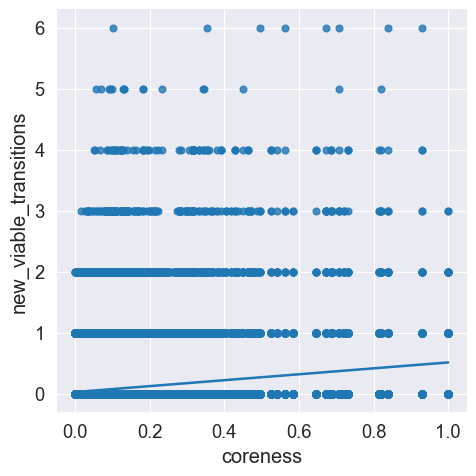

In [43]:
sns.lmplot(
    x="coreness", y="new_viable_transitions", x_ci="sd", data=df_upskilling_impact_v2
)

In [46]:
import pingouin as pg

df_upskilling_impact_v2.rcorr()

TypeError: corr() got an unexpected keyword argument 'numeric_only'

Text(0.5, 0, 'Target ISCO 3D groups')

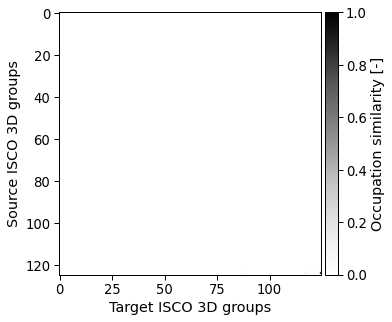

In [28]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(
    np.tril(occ_sims_isco3_upskilling - occ_sims_isco3), cmap="Greys", vmax=1
)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, orientation="vertical", label="Occupation similarity [-]")
ax.set_ylabel("Source ISCO 3D groups")
ax.set_xlabel("Target ISCO 3D groups")

Plots

Text(0.5, 0, 'Target ISCO 3D groups')

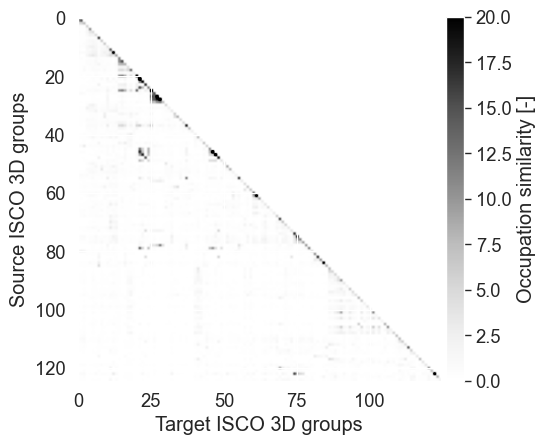

In [47]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(np.tril(df_occ_sims_isco3.values), cmap="Greys", vmax=20)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, orientation="vertical", label="Occupation similarity [-]")
ax.set_ylabel("Source ISCO 3D groups")
ax.set_xlabel("Target ISCO 3D groups")

To do: Aggregate skills coreness to ESCO skills hierarchy level 3 (unsuccessful yet)

In [48]:
coreness.sort_values("coreness", ascending=False)

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description,eigenvector_centrality,betweenness_centrality,betweenness_centrality_norm,mean_centrality,clustering_coefficient,coreness,skill_classification_esco
12391,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/e54ff029-1ce9...,skill/competence,cross-sector,train employees,train an employee\nteach employees\nupskill em...,NaN,released,2021-10-01T16:36:38.559Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Lead and guide employees through a process in ...,0.95,"2,295,023.03",0.87,0.91,0.07,1.00,neutral
3572,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/415abd43-e8e5...,skill/competence,cross-sector,use different communication channels,apply specific communication channels\noperate...,NaN,released,2016-12-20T18:56:53Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Make use of various types of communication cha...,0.68,"2,624,645.09",1.00,0.84,0.06,0.93,neutral
2856,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/339ac029-066a...,skill/competence,cross-sector,manage staff,coordinate and monitor employees\nmanage subor...,NaN,released,2016-12-20T20:30:17Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"Manage employees and subordinates, working in ...",0.82,"1,864,324.13",0.71,0.76,0.07,0.84,neutral
1821,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/21c5790c-0930...,skill/competence,cross-sector,manage budgets,NaN,NaN,released,2016-10-20T15:06:39Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"Plan, monitor and report on the budget.",0.93,"1,523,320.43",0.58,0.75,0.08,0.82,neutral
732,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0da516ee-e70e...,skill/competence,cross-sector,communicate with customers,talk with customers\ncommunicate with clients\...,NaN,released,2021-12-16T09:30:47.116Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Respond to and communicate with customers in t...,0.85,"1,732,220.14",0.66,0.75,0.08,0.81,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9751,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/b3950b87-a980...,knowledge,transversal,Lithuanian,ability to comprehend spoken and written Lithu...,NaN,released,2017-01-20T16:12:43Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,The Lithuanian language. Lithuanian is an offi...,0.00,0.00,0.00,0.00,NaN,0.00,neutral
3898,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/47a2917b-a771...,skill/competence,occupation-specific,use performance 3D visualisation techniques,NaN,NaN,released,2020-12-03T11:08:21.734Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Visualise a performance environment using 3D a...,0.01,0.00,0.00,0.00,1.00,0.00,neutral
3902,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/47b49f99-74a3...,knowledge,occupation-specific,coking process,coking processes\nprocesses of coking\nmaking ...,NaN,released,2017-01-03T16:32:46Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,The process of destructive distillation where ...,0.00,0.00,0.00,0.00,1.00,0.00,brown
9746,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/b383198f-1ed4...,skill/competence,occupation-specific,conduct leather finishing operations,NaN,NaN,released,2020-12-07T14:51:47.879Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Conduct finishing operations to produce leathe...,0.00,0.00,0.00,0.00,1.00,0.00,neutral


In [61]:
esco_skill_hierarchy = pd.read_csv(
    os.path.join("data", "raw", "esco", "v1.0.8", "skillsHierarchy_en.csv")
)
esco_skill_hierarchy.head()



,Level 0 URI,Level 0 preferred term,Level 1 URI,Level 1 preferred term,Level 2 URI,Level 2 preferred term,Level 3 URI,Level 3 preferred term,Description,Scope note,Level 0 code,Level 1 code,Level 2 code,Level 3 code
0,http://data.europa.eu/esco/skill/S,skills,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN
1,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",NaN,NaN,NaN,NaN,"Communicating, collaborating, liaising, and ne...",Excludes:\n- Communication or interaction with...,S,S1,NaN,NaN
2,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.0,"communication, collaboration and creativity",NaN,NaN,"Communicating, collaborating, liaising, and ne...",Excludes:\n- Communication or interaction with...,S,S1,S1.0,NaN
3,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.0,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.0.0,"communication, collaboration and creativity","Communicating, collaborating, liaising, and ne...",Excludes:\n- Communication or interaction with...,S,S1,S1.0,S1.0.0
4,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.1,negotiating,NaN,NaN,Exchanging ideas while analysing issues and in...,NaN,S,S1,S1.1,NaN


Can get to the 290 lvl 3 skill groups by filtering for skill/competence skill types, dropping the attitudes and lastly dropping nan values

In [62]:
print(esco_skill_hierarchy.columns)

Index(['Level 0 URI', 'Level 0 preferred term', 'Level 1 URI',
       'Level 1 preferred term', 'Level 2 URI', 'Level 2 preferred term',
       'Level 3 URI', 'Level 3 preferred term', 'Description', 'Scope note',
       'Level 0 code', 'Level 1 code', 'Level 2 code', 'Level 3 code'],
      dtype='object')


New CK script (tbc)

In [63]:
# Clean column names in case of leading/trailing spaces
esco_skill_hierarchy.columns = esco_skill_hierarchy.columns.str.strip()

In [64]:
# Filter the hierarchy dataset
esco_skill_hierarchy_subset = esco_skill_hierarchy.loc[
    (esco_skill_hierarchy["Level 0 preferred term"] == "skills") &
    (esco_skill_hierarchy["Level 0 code"] == "S")
].dropna(subset=["Level 1 preferred term", "Level 2 preferred term", "Level 3 preferred term"])

print(esco_skill_hierarchy_subset.head())

                          Level 0 URI Level 0 preferred term  \
3  http://data.europa.eu/esco/skill/S                 skills   
5  http://data.europa.eu/esco/skill/S                 skills   
6  http://data.europa.eu/esco/skill/S                 skills   
7  http://data.europa.eu/esco/skill/S                 skills   
8  http://data.europa.eu/esco/skill/S                 skills   

                           Level 1 URI  \
3  http://data.europa.eu/esco/skill/S1   
5  http://data.europa.eu/esco/skill/S1   
6  http://data.europa.eu/esco/skill/S1   
7  http://data.europa.eu/esco/skill/S1   
8  http://data.europa.eu/esco/skill/S1   

                        Level 1 preferred term  \
3  communication, collaboration and creativity   
5  communication, collaboration and creativity   
6  communication, collaboration and creativity   
7  communication, collaboration and creativity   
8  communication, collaboration and creativity   

                             Level 2 URI  \
3  http://data.eu

In [65]:
# Merge with coreness data
esco_skill_hierarchy_subset_coreness = pd.merge(
    esco_skill_hierarchy_subset,
    coreness[["preferredLabel", "coreness"]],
    left_on="Level 3 preferred term",
    right_on="preferredLabel",
    how="left"
)

print(esco_skill_hierarchy_subset_coreness.head())

                          Level 0 URI Level 0 preferred term  \
0  http://data.europa.eu/esco/skill/S                 skills   
1  http://data.europa.eu/esco/skill/S                 skills   
2  http://data.europa.eu/esco/skill/S                 skills   
3  http://data.europa.eu/esco/skill/S                 skills   
4  http://data.europa.eu/esco/skill/S                 skills   

                           Level 1 URI  \
0  http://data.europa.eu/esco/skill/S1   
1  http://data.europa.eu/esco/skill/S1   
2  http://data.europa.eu/esco/skill/S1   
3  http://data.europa.eu/esco/skill/S1   
4  http://data.europa.eu/esco/skill/S1   

                        Level 1 preferred term  \
0  communication, collaboration and creativity   
1  communication, collaboration and creativity   
2  communication, collaboration and creativity   
3  communication, collaboration and creativity   
4  communication, collaboration and creativity   

                             Level 2 URI  \
0  http://data.eu

Old FZ script (doesn't work either though)

In [54]:
# create a subset to merge

esco_skill_hierarchy_subset = esco_skill_hierarchy.loc[
    (esco_skill_hierarchy.skill_type == "skills")
    & (esco_skill_hierarchy.skill_category == "S")
].dropna(subset=["level_1", "level_2", "level_3"])

In [57]:
# merge

esco_skill_hierarchy_subset_coreness = pd.merge(
    esco_skill_hierarchy_subset,
    coreness[["preferredLabel", "coreness"]],
    on="preferredLabel",
    how="left",
)

KeyError: 'preferredLabel'

In [ ]:
esco_weighted_coreness = (
    esco_skill_hierarchy_subset_coreness.groupby("level_title").coreness.mean()
    / esco_skill_hierarchy_subset_coreness.groupby("level_title").count().coreness
)

Occupation similarity matrix based on ESCO occ skills tables

In [ ]:
occ_skill_table = pd.read_excel(
    os.path.join(data_raw, "esco", "en_Skills_Occupations Matrix Tables.xlsx"),
    sheet_name="Matrix 3.3",
)

# row multiindex
occ_skill_table = occ_skill_table.set_index(["Unnamed: 0", "Unnamed: 1"])
occ_skill_table.index.names = ["occ_uri", "occ"]

# column multiindex
col_indizes = [
    occ_skill_table.columns.values.tolist(),
    occ_skill_table.iloc[0, :].values.tolist(),
]
tuples = list(zip(*col_indizes))
col_index = pd.MultiIndex.from_tuples(tuples, names=["skill_uri", "skill"])
occ_skill_table.columns = col_index
occ_skill_table = occ_skill_table.iloc[1:, :]
occ_skill_table = occ_skill_table.astype(float)

# convert from fractions to percentages to avoid multiplication of values below 0
occ_skill_table *= 100

Correlation between occ skills tables and own co-occurrence matrix at ISCO 3 digit level

In [ ]:
occ_sims = np.matmul(occ_skill_table.values, occ_skill_table.values.transpose())
df_occ_sims = pd.DataFrame(
    index=occ_skill_table.index, columns=occ_skill_table.index, data=occ_sims
)

In [ ]:
np.corrcoef(df_occ_sims_isco3.values.flatten(), df_occ_sims.values.flatten())